In [1]:
# ============================================================
# PART 1 — Setup and experimental dataset
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import emcee, corner

# Global plot style
plt.rcParams.update({
    "font.family": "sans-serif",
    "mathtext.fontset": "dejavusans",
    "font.size": 14,
    "axes.labelsize": 17,
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.8,
})

np.random.seed(1234)

# Load experimental homodyne data
x_all      = np.load("spdc10mw.npy").ravel()
phases_all = np.load("spdc10mw_theta.npy").ravel()

# Shuffle once while preserving each (phase, quadrature) pair
idx        = np.random.permutation(len(x_all))
x_all      = x_all[idx]
phases_all = phases_all[idx]

N_max = len(x_all)

print("Experimental dataset size:",N_max)

Experimental dataset size: 62868


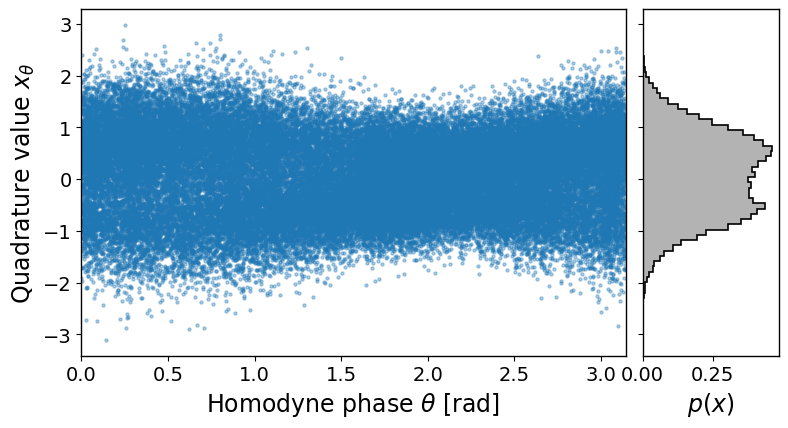

In [18]:
# ============================================================
# PART 2 — Experimental homodyne quadrature sequence
# ============================================================

N_plot = min(100000,N_max)

ph_plot = phases_all[:N_plot]
x_plot  = x_all[:N_plot]
order   = np.argsort(ph_plot)

fig = plt.figure(figsize=(9,4.5))
gs  = fig.add_gridspec(1,2,width_ratios=[4,1],wspace=0.05)

ax  = fig.add_subplot(gs[0])
axh = fig.add_subplot(gs[1],sharey=ax)

# Homodyne quadrature sequence
ax.scatter(ph_plot[order],x_plot[order],s=5,alpha=0.35)

ax.set_xlabel(r"Homodyne phase $\theta$ [rad]")
ax.set_ylabel(r"Quadrature value $x_\theta$")
ax.set_xlim(0,np.pi)

# Marginal quadrature distribution
axh.hist(x_plot,bins=60,density=True,orientation="horizontal",
         histtype="stepfilled",color="0.7",
         edgecolor="black",linewidth=1.2)

axh.set_xlabel(r"$p(x)$")
axh.tick_params(axis="y",labelleft=False)

plt.savefig("experimental_nongaussian_quadrature_sequence.pdf",
            bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# PART 3 — MCMC inference for a selected data size
# ============================================================

def run_mcmc(N_data,nsteps=5000,nwalkers=32,discard=1500,thin=5):
    x = x_all[:N_data]

    def log_post(params):
        params = np.atleast_2d(params)
        c = params[:,0]

        valid = (0 <= c) & (c <= 1)
        out   = np.full(len(params),-np.inf)
        if not np.any(valid): return out

        cc = c[valid,None]
        xx = x[None,:]

        p0 = np.sqrt(2/np.pi)*np.exp(-2*xx**2)
        p1 = 4*np.sqrt(2/np.pi)*xx**2*np.exp(-2*xx**2)
        p  = np.clip(cc*p0 + (1-cc)*p1,1e-300,None)

        out[valid] = np.sum(np.log(p),axis=1)
        return out

    p0 = np.random.uniform(0,1,size=(nwalkers,1))

    sampler = emcee.EnsembleSampler(nwalkers,1,log_post,vectorize=True)
    sampler.run_mcmc(p0,nsteps,progress=False)

    return sampler.get_chain(discard=discard,thin=thin,flat=True)

In [14]:
# ============================================================
# PART 4 — Data-size convergence study
# ============================================================

N_candidates = [50,100,200,500,1000,2000,5000,10000,
                20000,50000,100000,150000,200000]

N_list = [N for N in N_candidates if N < N_max]
N_list.append(N_max)

results = []
saved_samples = {}

for N in N_list:
    print(f"Running N = {N}...")
    samples = run_mcmc(N)

    q16,q50,q84 = np.percentile(samples.ravel(),[16,50,84])
    results.append((N,q16,q50,q84))
    saved_samples[N] = samples

Ns      = np.array([r[0] for r in results])
q16s    = np.array([r[1] for r in results])
medians = np.array([r[2] for r in results])
q84s    = np.array([r[3] for r in results])
widths  = q84s-q16s

Running N = 50...
Running N = 100...
Running N = 200...
Running N = 500...
Running N = 1000...
Running N = 2000...
Running N = 5000...
Running N = 10000...
Running N = 20000...
Running N = 50000...
Running N = 62868...


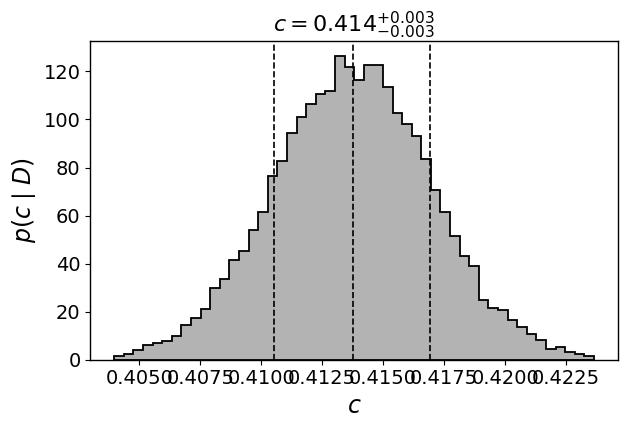

In [15]:
# ============================================================
# PART 5 — Posterior distribution
# ============================================================

N_show       = N_list[-1]
samples_show = saved_samples[N_show].ravel()

q16,q50,q84 = np.percentile(samples_show,[16,50,84])
q            = np.percentile(samples_show,[0.5,99.5])
pad          = 0.08*(q[1]-q[0])

fig,ax = plt.subplots(figsize=(6.5,4.5))

ax.hist(samples_show,bins=50,range=(q[0]-pad,q[1]+pad),density=True,
        histtype="stepfilled",color="0.7",
        edgecolor="black",linewidth=1.3)

for v in [q16,q50,q84]:
    ax.axvline(v,color="black",ls="--",lw=1.2)

ax.set_xlabel(r"$c$")
ax.set_ylabel(r"$p(c\mid D)$")
ax.set_title(
    rf"$c={q50:.3f}^{{+{q84-q50:.3f}}}_{{-{q50-q16:.3f}}}$"
)

plt.tight_layout()
plt.savefig("experimental_nongaussian_posterior_plot.pdf",
            bbox_inches="tight")
plt.show()

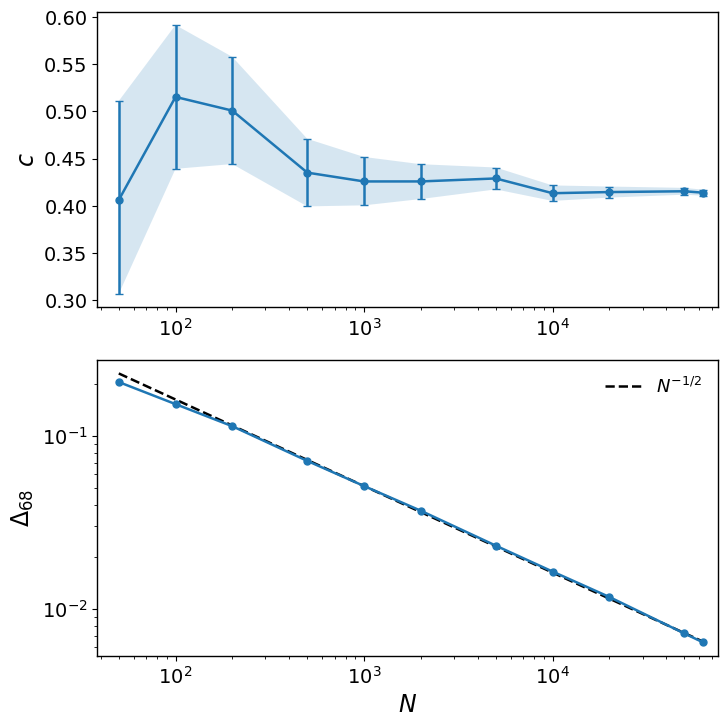

In [16]:
# ============================================================
# PART 6 — Bayesian stabilization and posterior contraction
# ============================================================

fig,axs = plt.subplots(2,1,figsize=(7.5,7.5))

# Top: posterior estimate
yerr = np.vstack((medians-q16s,q84s-medians))

axs[0].errorbar(Ns,medians,yerr=yerr,fmt="o-",ms=5,capsize=3)
axs[0].fill_between(Ns,q16s,q84s,alpha=0.18)

axs[0].set_xscale("log")
axs[0].set_xlim(Ns[0]/1.3,Ns[-1]*1.2)
axs[0].set_ylabel(r"$c$")

# Bottom: posterior contraction
idx_ref = np.argmin(np.abs(Ns-1000))
ref = widths[idx_ref]*np.sqrt(Ns[idx_ref]/Ns)

axs[1].plot(Ns,widths,"o-",ms=5,zorder=2)
axs[1].plot(Ns,ref,"--",color="black",
            label=r"$N^{-1/2}$",zorder=1)

axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_xlim(Ns[0]/1.3,Ns[-1]*1.2)
axs[1].set_xlabel(r"$N$")
axs[1].set_ylabel(r"$\Delta_{68}$")
axs[1].legend(frameon=False)

plt.tight_layout()
plt.savefig("experimental_nongaussian_bayesian_stabilization_and_contraction.pdf",
            bbox_inches="tight")
plt.show()

In [17]:
# ============================================================
# PART 7 — Fixed-axis posterior GIF
# ============================================================

import os
from PIL import Image

gif_N     = N_list
frame_dir = "posterior_gif_frames"
os.makedirs(frame_dir,exist_ok=True)

# Fixed x-range from all posterior samples
all_samples = np.concatenate([saved_samples[N].ravel() for N in gif_N])
q           = np.percentile(all_samples,[0.5,99.5])
pad         = 0.08*(q[1]-q[0])
plot_range  = (q[0]-pad,q[1]+pad)

# Fixed y-range from all histograms
bins  = 50
y_max = 0.0

for N in gif_N:
    hist,_ = np.histogram(saved_samples[N].ravel(),
                          bins=bins,range=plot_range,density=True)
    y_max = max(y_max,hist.max())

y_max *= 1.08
frame_paths = []

for N in gif_N:
    samples     = saved_samples[N].ravel()
    q16,q50,q84 = np.percentile(samples,[16,50,84])

    fig,ax = plt.subplots(figsize=(6.5,4.5))

    ax.hist(samples,bins=bins,range=plot_range,density=True,
            histtype="stepfilled",color="0.7",
            edgecolor="black",linewidth=1.3)

    for v in [q16,q50,q84]:
        ax.axvline(v,color="black",ls="--",lw=1.2)

    ax.set_xlim(plot_range)
    ax.set_ylim(0,y_max)
    ax.set_xlabel(r"$c$")
    ax.set_ylabel(r"$p(c\mid D)$")
    ax.set_title(
        rf"$N={N:,}$" + "\n" +
        rf"$c={q50:.3f}^{{+{q84-q50:.3f}}}_{{-{q50-q16:.3f}}}$"
    )

    path = os.path.join(frame_dir,f"posterior_N_{N:06d}.png")
    fig.savefig(path,dpi=120,facecolor="white",bbox_inches="tight")
    plt.close(fig)
    frame_paths.append(path)

frames = [Image.open(path) for path in frame_paths]
frames = [frames[0]]*2 + frames + [frames[-1]]*3

frames[0].save(
    "experimental_nongaussian_posterior_convergence.gif",
    save_all=True,
    append_images=frames[1:],
    duration=300,
    loop=0
)

print("Saved: experimental_nongaussian_posterior_convergence.gif")

Saved: experimental_nongaussian_posterior_convergence.gif
